In [1]:
%matplotlib inline

# Hand Coded Perceptron in NumPy

Let's look at the famous nonlinear XOR problem and the Perceptron

No learning algorithm below, we are just looking at a user defined (you!!!) solution

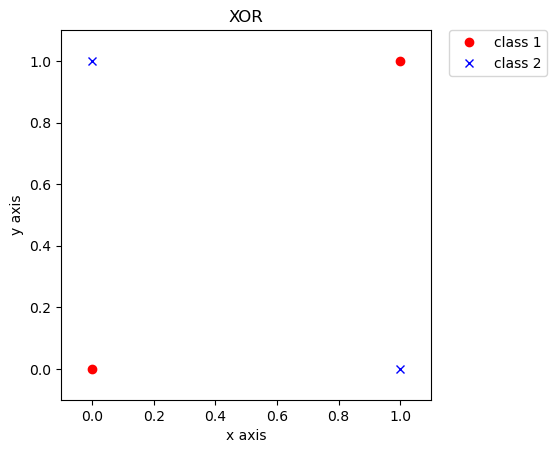

In [2]:
# this is a comment in Python!

import numpy as np # include the numpy library for ops on arrays as the name "np"
import matplotlib.pyplot as plt # include the plotting library as the name "plt"

# XOR data points: asarray takes list format and converts it into an array
X1 = np.asarray([[1, 1], [0, 0]]) # class 1, points (1,1) and (0,0)
X2 = np.asarray([[1, 0], [0, 1]]) # class 2, points (1,0) and (0,1)

# plot them
plt.plot(X1[:,0],X1[:,1],'ro',label="class 1") # draw red (r) and circle (0)
                                               # : says all in that dim!
plt.plot(X2[:,0],X2[:,1],'bx',label="class 2") # draw blue (b) and an "x" (x)
# figure title and axis labels 
plt.title('XOR') 
plt.xlabel('x axis')
plt.ylabel('y axis')
# draw x and y equal spacing
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend(bbox_to_anchor=(1.05,1),loc=2,borderaxespad=0)
plt.show()

Now, lets pick a weight vector and plot it

In [3]:
# weight vector 
w = np.asarray([1.1, 1.1, -1]) # weight 1 = 1.1, weight 2 = 1.1, bias = -1
print(w)

[ 1.1  1.1 -1. ]


In [4]:
# lets do the calculation for our four points

for i in range(2):
    print( "Output of " + str( np.dot(w[0:2],X1[i,:]) + 1*w[2] ) + " for input " + str( X1[i,:] ) )

for i in range(2):
    print( "Output of " + str( np.dot(w[0:2],X2[i,:]) + 1*w[2] ) + " for input " + str( X2[i,:] ) )

Output of 1.2000000000000002 for input [1 1]
Output of -1.0 for input [0 0]
Output of 0.10000000000000009 for input [1 0]
Output of 0.10000000000000009 for input [0 1]


note: the range function: https://www.pythoncentral.io/pythons-range-function-explained/
  * range(start,stop,step)

Next, we can calculate the x and y intercepts (for geometric view of Perceptron)

i.e., where our perceptron, line in two dimensions, crosses the "x" and "y" axes

In [5]:
print( "x intercept is " + str( (-1) * (w[2]/w[0]) ) )
print( "y intercept is " + str( (-1) * (w[2]/w[1]) ) )

x intercept is 0.9090909090909091
y intercept is 0.9090909090909091


Lets "draw" (by rasterizing the space) a decision surface

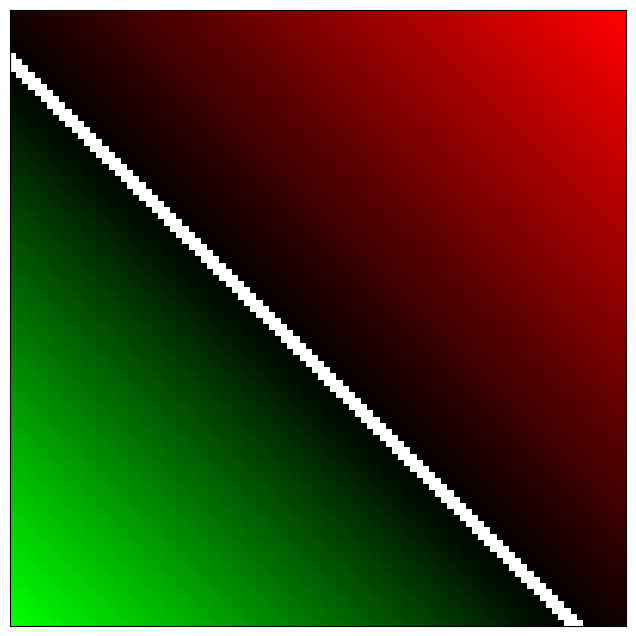

In [6]:
import math

# step size from sample to sample 
Delta = 0.01
# bounds to render (so, [0,1] gives us 0 to 1)
Bounds = np.asarray([0,1])
# how many samples to make
Res = math.ceil((Bounds[1] - Bounds[0]) / Delta)

# store our perceptron result
Result = np.zeros([Res,Res])
for i in range(Res):
    for j in range(Res):
        # our coordinate, aka data point
        ind_i = Bounds[0] + (i*Delta)
        ind_j = Bounds[0] + (j*Delta)        
        # result of perceptron
        Result[i,j] = np.dot(w[0:2],np.asarray([ind_i, ind_j])) + 1*w[2]  

# figure out the smallest and biggest numbers (to show as an image with [0,1] or [0,255])
SmallNum = np.amin( Result )
BigNum = np.amax( Result )

# make our results into an image
ResultColor = np.zeros([Res,Res,3]) # for RGB
for i in range(Res):
    for j in range(Res):      
        if( np.abs(Result[i,j]) < 0.02 ): # decision boundary
            ResultColor[i,j,:] = np.asarray([1,1,1])
        elif( Result[i,j] > 0 ): # class 1
            ResultColor[i,j,:] = np.asarray([1,0,0]) * (Result[i,j] / BigNum)
        else: # class 2
            ResultColor[i,j,:] = np.asarray([0,1,0]) * (Result[i,j] / SmallNum)
                        
# render it
fig = plt.figure(figsize = (8,8))
fig = plt.imshow(np.flipud(ResultColor))
fig.axes.get_xaxis().set_visible(False)
fig.axes.get_yaxis().set_visible(False)
plt.show()

I normalized each class/region between the min and max observed value for pretty display. 

Have fun, play around with X1 and X2 above and also the weight terms!

# Reflection 

Address the following

1) Change the color of the plotted image

2) Plot units on the figure axes

3) Look up "val = input("give me some input")" and ask the user for a weight vector